In [ ]:
import torch
import numpy as np
import pandas as pd


In [ ]:
!pip install einops

In [ ]:
#import rearrange
from einops import rearrange, reduce, repeat
from einops.layers.torch import Rearrange, Reduce

In [ ]:
class PositionalEncoding(torch.nn.Module):

    def __init__(self, d_model: int, dropout: float = 0.1, max_len: int = 5000):
        super().__init__()
        self.dropout = torch.nn.Dropout(p=dropout)

        position = torch.arange(max_len).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2) * (-torch.math.log(10000.0) / d_model))
        pe = torch.zeros(max_len, 1, d_model)
        pe[:, 0, 0::2] = torch.sin(position * div_term)
        pe[:, 0, 1::2] = torch.cos(position * div_term)
        self.register_buffer('pe', pe)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Arguments:
            x: Tensor, shape ``[seq_len, batch_size, embedding_dim]``
        """
        x = x + self.pe[:x.size(0)]
        return self.dropout(x)

In [ ]:
class MFC(torch.nn.Module):
  def __init__(self,emb_dim,n_heads,dropout1,dropout2):
    super(MFC,self).__init__()
    self.emb_dim=emb_dim
    self.n_heads=n_heads
    self.att=torch.nn.MultiheadAttention(embed_dim=emb_dim,num_heads=n_heads,dropout=dropout1)
    self.linear1=torch.nn.Linear(emb_dim,emb_dim)
    self.activation1=torch.nn.LeakyReLU()
    self.dropout2=dropout2
    self.dropout2layer=torch.nn.Dropout(dropout2)
    self.linear2=torch.nn.Linear(emb_dim,emb_dim)
  def forward(self,q,k,v,mask):
    if mask is None:
      mask=torch.zeros((q.shape[1],q.shape[1]))
    res=self.att(q,k,v)[0]
    #print("hires")
    #print(res.shape)
    q=torch.nn.LayerNorm(self.emb_dim)(q+res)
    res2=self.linear1(q)
    res2=self.activation1(res2)

    res2=self.dropout2layer(res2)
    #res2=self.linear2(res2)
    q=torch.nn.LayerNorm(self.emb_dim)(q+res2)
    return q

In [ ]:
class PatchPartition(torch.nn.Module):
    def __init__(self, patch_size,window_size):
        super().__init__()
        self.window_size = window_size
        self.patch_size = patch_size
    def forward(self,x):
      #image of dimension (b,h,w,c)
      x=rearrange(x,"b (h p1 w1 ) (w p2 w2) c -> b (h w)  (w1 w2) (p1 p2 c) ",p1=self.patch_size,w1=self.window_size,p2=self.patch_size,w2=self.window_size)
      return x

class PatchMerge(torch.nn.Module):
    def __init__(self, patch_size,window_size,emb_dim):
        super().__init__()
        self.window_size = window_size
        self.patch_size = patch_size
        self.linear=torch.nn.Linear(emb_dim*2,emb_dim)
        self.GELU=torch.nn.GELU()
    def forward(self,x):
      #dimension = (b,w,p,f)
      patchn=x.shape[2]
      cls_token,x=x[:,:,0,:],x[:,:,1:,:]
      windowsn=x.shape[1]
      x=rearrange(x," b w n f -> b (w n) f ")

      #newp=x.shape[1]//2
      #x=rearrange(x,"b (pd 2) f -> b pd (f 2)")
      if x.shape[1]%2!=0:
        x=torch.cat([x,torch.zeros(1,1,x.shape[2])],dim=1)
      #print("exs")
      #print(x.shape)
      x=torch.reshape(x,(x.shape[0],x.shape[1]//2,2*x.shape[2]))
      x=self.linear(x)
      x=self.GELU(x)
      if x.shape[1]%windowsn !=0:
        diff=(x.shape[1]-1)%windowsn
        pad=torch.zeros(x.shape[0],diff,x.shape[2])
        x=torch.cat([x,pad],dim=1)

      x=rearrange(x,"b (w n) f -> b w n f", w=windowsn)
      #print("exss")
      cls_token=cls_token.unsqueeze(2)
      #print(cls_token.shape)
      #cls_token=torch.reshape(cls_token,(1,cls_token.shape[2],1,100))
      #print("lol")
      #print(x.shape)
      x=torch.cat([cls_token,x],dim=2)
      #print("exsss")
      #print(x.shape)
      return x





In [ ]:
class LinearEmbedding(torch.nn.Module):
  def __init__(self,out,emb_dim,nwindows):
    super().__init__()
    self.outdim=out
    self.emb_dim=emb_dim
    self.nwindows=nwindows
    self.linear=torch.nn.Linear(self.outdim,self.emb_dim)
    self.GELU=torch.nn.SELU()
  def forward(self,x):
    #numberpatches=x.shape[2]
    x=rearrange(x,"b w np f -> b (w np) f ")
    x=self.linear(x)
    x=self.GELU(x)
    x=rearrange(x,"b (w np) f -> b w np f",w=self.nwindows)
    return x



In [ ]:
class SwinTransformerBlock(torch.nn.Module):
  def __init__(self,emb_dim,shift,posencoding):
    super().__init__()
    self.posencoding=posencoding
    self.positionenc=PositionalEncoding(emb_dim)
    self.norm1=torch.nn.LayerNorm(emb_dim)
    self.wmhatt=torch.nn.MultiheadAttention(emb_dim,10,0.2)
    self.norm2=torch.nn.LayerNorm(emb_dim)
    self.mlp=torch.nn.Sequential(
        torch.nn.Linear(emb_dim,emb_dim*4),
        torch.nn.GELU(),
        torch.nn.Linear(emb_dim*4,emb_dim)
    )
    self.norm3=torch.nn.LayerNorm(emb_dim)
    self.swmhatt=torch.nn.MultiheadAttention(emb_dim,10,0.2)
    self.norm4=torch.nn.LayerNorm(emb_dim)
    self.mlp2=torch.nn.Sequential(
        torch.nn.Linear(emb_dim,emb_dim*4),
        torch.nn.GELU(),
        torch.nn.Linear(emb_dim*4,emb_dim)
    )
    self.shift=shift
  def forward(self,x):
    #empty tensor
    out=torch.empty(x.shape)
    for i in range(x.shape[1]):
      window=x[:,i,:,:]
      if self.posencoding:
        window=self.positionenc(window)
      window=window.squeeze(0)
      #print("deded")
      #print(window.shape)
      residual1=self.norm1(window)
      residual1, _ = self.wmhatt(residual1, residual1, residual1)
      window = window + residual1
      residual2 = self.norm2(window)
      residual2 = self.mlp(residual2)
      window = window + residual2
      window=window.unsqueeze(0)
      out[:,i,:,:]=window

    #shift out
    #print(out[:,0,:,:])
    out=rearrange(out,"b w np f -> b (w np) f")
    out=torch.roll(out,-self.shift,dims=1)
    out=rearrange(out,"b (w np) f -> b w np f",w=x.shape[1])
    #print(out[:,0,:,:])
    out2=torch.empty(x.shape)
    for i in range(x.shape[1]):
      window=out[:,i,:,:]
      window=window.squeeze(0)
      residual1=self.norm3(window)
      residual1, _ = self.swmhatt(residual1, residual1, residual1)
      window = window + residual1
      residual2 = self.norm4(window)
      residual2 = self.mlp2(residual2)
      window = window + residual2
      window=window.unsqueeze(0)
      out2[:,i,:,:]=window
    out2=rearrange(out2,"b w np f -> b (w np) f")
    out2=torch.roll(out2,self.shift,dims=1)
    out2=rearrange(out2,"b (w np) f -> b w np f",w=x.shape[1])
    return out2




In [ ]:
#bayesian

class BayesianBlock(torch.nn.Module):

   def __init__(self, in_channels, out_channels):
         super(BayesianBlock, self).__init__()
         self.in_channels = in_channels
         self.out_channels = out_channels
         self.Linear1 = torch.nn.Linear(in_channels, out_channels*2)
         self.activation1 = torch.nn.LeakyReLU()
   def forward(self, x):
         x = self.Linear1(x)
         x = self.activation1(x)
         #redimension
         mu=x[:self.out_channels]
         sigma=x[self.out_channels:]
         distribution = torch.distributions.Normal(mu, torch.nn.Softplus()(sigma))
         rsample=distribution.rsample()
         return rsample,distribution


In [ ]:
class BayesianBlockWeight(torch.nn.Module):

   def __init__(self, in_features, out_features):
         super(BayesianBlockWeight, self).__init__()
         self.in_features = in_features
         self.out_features = out_features
         self.mean_matrix=torch.nn.Parameter(torch.randn(out_features,in_features))
         self.sigma_matrix=torch.nn.Parameter(torch.randn(out_features,in_features))

   def forward(self, x):
         distribution = torch.distributions.Normal(self.mean_matrix, torch.nn.Softplus()(self.sigma_matrix))
         rsample=distribution.rsample()
         print(rsample.shape)
         x=torch.matmul(x,rsample.T)
         return x,distribution


In [ ]:
def kl_divergence(dist1, dist2):
    kl_t=0
    for i in dist1:
     kl_m=torch.distributions.kl.kl_divergence(dist1, dist2)
     kl_m=torch.nn.Flatten()(kl_m)
     kl_m=torch.mean(kl_m)
     kl_t+=kl_m
    return kl_m/len(dist1)

In [ ]:
#test
input=torch.randn((1,15))
basb=BayesianBlockWeight(15,10)
input,distd=basb(input)
#print(input.shape)
#print(distd.mean)
#print(distd.stddev)
kl_divergenc=kl_divergence(distd,distd)
print(kl_divergenc)




torch.Size([10, 15])
tensor(0., grad_fn=<MeanBackward0>)


In [ ]:
class mdp(torch.nn.Module):
  def __init__(self,inb,out,dropout):
    super(mdp,self).__init__()
    self.in_channels=inb
    self.out_channels=out
    self.Linear1 = torch.nn.Linear(inb, out)
    self.activation1 = torch.nn.LeakyReLU()
    self.dropout=dropout
    self.dropoutlayer=torch.nn.Dropout(dropout)
  def forward(self,x):
    x=self.Linear1(x)
    x=self.activation1(x)
    x=self.dropoutlayer(x)
    return x


In [ ]:
class SwinModel(torch.nn.Module):
  def __init__(self,wsize,psize,emb_dim,gt_dim):
    super().__init__()
    self.wsize=wsize
    self.psize=psize
    self.emb_dim=emb_dim
    self.patchpartition=PatchPartition(self.psize,self.wsize)
    self.linear=LinearEmbedding(self.psize*self.psize*3,self.emb_dim,25)
    self.cls=torch.nn.Parameter(torch.randn(1,1,1,self.psize*self.psize*3))
    self.cls2=torch.nn.Parameter(torch.randn(1,gt_dim))
    self.swinblock1=SwinTransformerBlock(self.emb_dim,5,True)
    self.patchmerge1=PatchMerge(self.psize,self.wsize,emb_dim)
    self.swinblock2=SwinTransformerBlock(self.emb_dim,5,False)
    self.patchmerge2=PatchMerge(self.psize,self.wsize,emb_dim)
    self.swinblock3=SwinTransformerBlock(self.emb_dim,5,False)
    self.patchmerge3=PatchMerge(self.psize,self.wsize,emb_dim)
    self.posenc=PositionalEncoding(self.emb_dim)
    #self.crossattention=torch.nn.MultiheadAttention(self.emb_dim,10,0.2)
    self.mfcgt=MFC(100,5,0.2,0.2)
    self.mfcgt2=MFC(100,5,0.2,0.2)
    self.lineargt=torch.nn.Linear(gt_dim,self.emb_dim)
    self.activationgt=torch.nn.GELU()
    #decoder
    self.bayesian1=BayesianBlock(self.emb_dim,70)
    self.bayesian2=BayesianBlock(70,50)
    self.bayesian3=BayesianBlock(50,25)
    self.bayesian4=BayesianBlock(25,10)
    self.bayesian5=BayesianBlock(10,5)
    self.bayesian6=BayesianBlock(5,2)
    self.sigmoid=torch.nn.Sigmoid()
  def forward(self,x,gt):
    dist=[]
    x=self.patchpartition(x)
    #add cls to each window
    #print(x.shape)
    cls=torch.repeat_interleave(self.cls,x.shape[1],dim=1)
    #print(cls.shape)
    x=torch.cat([cls,x],dim=2)
    x=self.linear(x)
    x=self.swinblock1(x)
    x=self.patchmerge1(x)
    x=self.swinblock2(x)
    x=self.patchmerge2(x)
    x=self.swinblock3(x)
    #x=self.patchmerge3(x)
    print("s")
    print(x.shape)
    # get cls
    x=x[:,:,0,:]
    x=torch.squeeze(x,0)
    if gt is not None:
      #empty tensor
      empty=torch.empty((gt.shape[0]-1,gt.shape[1]))


      for i in range(gt.shape[0]-1):
        sgt=gt[:(i+1),:]
        #sgt=torch.cat([self.cls2,sgt],dim=0)
        #print("esgiti")
        #print(sgt.shape)
        #pos encoding
        sgt=torch.unsqueeze(sgt,0)
        #sgt=self.posenc(sgt)
        sgt=sgt.squeeze(0)
        #print("lool")
        #print(sgt.shape)
        #print(x.shape)
        #pad
        mask=None
        if sgt.shape[0]<gt.shape[0]:
          diff=gt.shape[0]-sgt.shape[0]
          pad=torch.zeros(diff,sgt.shape[1])
          sgt=torch.cat([sgt,pad],dim=0)
          #mask
          zeroes=torch.zeros(sgt.shape[0]+1-diff,x.shape[0])
          ones=torch.ones(diff,x.shape[0])
          mask1=torch.cat([zeroes,ones],dim=0)
          zeroes=torch.zeros(sgt.shape[0]+1-diff,sgt.shape[0])
          ones=torch.ones(diff,sgt.shape[0])
          mask2=torch.cat([zeroes,ones],dim=0)
        sgt=torch.cat([self.cls2,sgt],dim=0)
        sgt=self.lineargt(sgt)
        sgt=self.activationgt(sgt)
        #sgt=torch.cat([self.cls2,sgt],dim=0)
        #print("lolk")
        #print(sgt.shape)

        sgt=sgt.unsqueeze(0)
        #print(sgt.shape)
        sgt=self.posenc(sgt)
        sgt=sgt.squeeze(0)
        #print(sgt.shape)
        sgt=self.mfcgt(sgt,x,x,None)
        sgt=self.mfcgt2(sgt,x,x,None)
        #context vector
        sgt=sgt[0,:]
        sgt,distd=self.bayesian1(sgt)
        dist.append(distd)
        sgt,distd=self.bayesian2(sgt)
        dist.append(distd)
        sgt,distd=self.bayesian3(sgt)
        dist.append(distd)
        sgt,distd=self.bayesian4(sgt)
        dist.append(distd)
        sgt,distd=self.bayesian5(sgt)
        dist.append(distd)
        sgt,distd=self.bayesian6(sgt)
        dist.append(distd)
        #sgt=self.sigmoid(sgt)
        empty[i,:]=sgt
        #print("xd")
        #print(mask1)
        #print(mask2)
      empty=torch.nn.Tanh()(empty)

      return empty,dist





        #sgt=sgt.squeeze(0)
        #print(diff)





          #ones=torch.ones(gt.shape[0]-sgt.shape[0],sgt.shape[0])









In [ ]:
class SwinModel(torch.nn.Module):
  def __init__(self,wsize,psize,emb_dim,gt_dim):
    super().__init__()
    self.wsize=wsize
    self.psize=psize
    self.emb_dim=emb_dim
    self.patchpartition=PatchPartition(self.psize,self.wsize)
    self.linear=LinearEmbedding(self.psize*self.psize*3,self.emb_dim,25)
    self.cls=torch.nn.Parameter(torch.ones(1,1,1,self.psize*self.psize*3))
    self.cls2=torch.nn.Parameter(torch.ones(1,gt_dim))
    self.swinblock1=SwinTransformerBlock(self.emb_dim,5,True)
    #self.patchmerge1=PatchMerge(self.psize,self.wsize,emb_dim)
    self.swinblock2=SwinTransformerBlock(self.emb_dim,5,False)
    #self.patchmerge2=PatchMerge(self.psize,self.wsize,emb_dim)
    self.swinblock3=SwinTransformerBlock(self.emb_dim,5,False)
    #self.patchmerge3=PatchMerge(self.psize,self.wsize,emb_dim)
    self.posenc=PositionalEncoding(self.emb_dim)
    #self.crossattention=torch.nn.MultiheadAttention(self.emb_dim,10,0.2)
    self.mfcgt=MFC(100,5,0.2,0.2)
    self.mfcgt2=MFC(100,5,0.2,0.2)
    self.mfcgt3=MFC(100,5,0.2,0.2)
    self.mfcgt4=MFC(100,5,0.2,0.2)
    self.mfcgt5=MFC(100,5,0.2,0.2)
    self.lineargt=torch.nn.Linear(gt_dim,self.emb_dim)
    self.activationgt=torch.nn.GELU()
    #decoder
    self.bayesian1=BayesianBlock(self.emb_dim,70)
    self.bayesian2=BayesianBlock(70,50)
    self.bayesian3=mdp(50,25,0.1)
    self.bayesian4=mdp(25,10,0.1)
    self.bayesian5=mdp(10,5,0.1)
    self.bayesian6=mdp(5,2,0.1)
    self.sgtlayernorm=torch.nn.LayerNorm(100)
    self.sgtlayernorm2=torch.nn.LayerNorm(100)
    self.xnorm=torch.nn.LayerNorm(self.emb_dim)
    self.sigmoid=torch.nn.Sigmoid()

  def forward(self,x,gt):
    dist=[]
    x=self.patchpartition(x)
    #add cls to each window
    #print(x.shape)
    #cls=torch.repeat_interleave(self.cls,x.shape[1],dim=1)
    #print(cls.shape)
    #x=torch.cat([cls,x],dim=2)
    x=self.linear(x)
    x=self.swinblock1(x)
    #x=self.patchmerge1(x)
    x=self.swinblock2(x)
    #x=self.patchmerge2(x)
    x=self.swinblock3(x)
    #x=self.patchmerge3(x)
    print("s")
    print(x.shape)
    # global pooling
    #x=x[:,:,0,:]
    x=torch.mean(x,dim=2)
    print("ex sh")
    print(x.shape)

    #pos enc
    x=self.posenc(x)
    x=torch.squeeze(x,0)
    x=self.xnorm(x)
    #print("first cls")
    #print(x)
    if gt is not None:
      #empty tensor
      empty=torch.empty((gt.shape[0]-1,gt.shape[1]))
      #gt=torch.nn.Sigmoid()(gt)


      for i in range(gt.shape[0]-1):
        sgt=gt[:(i+1),:]
        #sgt=torch.cat([self.cls2,sgt],dim=0)
        #print("esgiti")
        #print(sgt.shape)
        #pos encoding
        sgt=torch.unsqueeze(sgt,0)
        #sgt=self.posenc(sgt)
        sgt=sgt.squeeze(0)
        #print("lool")
        #print(sgt.shape)
        #print(x.shape)
        #pad
        mask=None
        if sgt.shape[0]<gt.shape[0]:
          diff=gt.shape[0]-sgt.shape[0]
          pad=torch.zeros(diff,sgt.shape[1])
          sgt=torch.cat([sgt,pad],dim=0)
          #mask
          zeroes=torch.zeros(sgt.shape[0]+1-diff,x.shape[0])
          ones=torch.ones(diff,x.shape[0])
          mask1=torch.cat([zeroes,ones],dim=0)
          zeroes=torch.zeros(sgt.shape[0]+1-diff,sgt.shape[0])
          ones=torch.ones(diff,sgt.shape[0])
          mask2=torch.cat([zeroes,ones],dim=0)
        #sgt=torch.cat([self.cls2,sgt],dim=0)
        sgt=self.lineargt(sgt)
        sgt=self.activationgt(sgt)
        #layernorm
        sgt=self.sgtlayernorm(sgt)
        #sgt=torch.cat([self.cls2,sgt],dim=0)
        #print("lolk")
        #print(sgt.shape)

        sgt=sgt.unsqueeze(0)
        #print(sgt.shape)
        sgt=self.posenc(sgt)
        sgt=sgt.squeeze(0)
        #print(sgt.shape)
        sgt=self.mfcgt(sgt,x,x,None)
        sgt=self.mfcgt2(sgt,x,x,None)
        sgt=self.mfcgt3(sgt,x,x,None)
        sgt=self.mfcgt4(sgt,x,x,None)
        sgt=self.mfcgt5(sgt,x,x,None)

        #context vector
        #sgt=sgt[0,:]
        #global pooling
        sgt=torch.mean(sgt,dim=0)
        print("cls 2")
        print(sgt.shape)
        sgt=self.sgtlayernorm2(sgt)

        sgt,distd=self.bayesian1(sgt)
        dist.append(distd)
        sgt,distd=self.bayesian2(sgt)
        dist.append(distd)
        sgt=self.bayesian3(sgt)
        #dist.append(distd)
        sgt=self.bayesian4(sgt)
        #dist.append(distd)
        sgt=self.bayesian5(sgt)
        #dist.append(distd)
        sgt=self.bayesian6(sgt)
        #dist.append(distd)
        #sgt=self.sigmoid(sgt)
        empty[i,:]=sgt
        #print("xd")
        #print(mask1)
        #print(mask2)
      #empty=torch.nn.Tanh()(empty)

      return empty,dist





        #sgt=sgt.squeeze(0)
        #print(diff)





          #ones=torch.ones(gt.shape[0]-sgt.shape[0],sgt.shape[0])









In [ ]:
class SwinModel2(torch.nn.Module):
  def __init__(self,wsize,psize,emb_dim,gt_dim):
    super().__init__()
    self.wsize=wsize
    self.psize=psize
    self.emb_dim=emb_dim
    self.patchpartition=PatchPartition(self.psize,self.wsize)
    self.linear=LinearEmbedding(self.psize*self.psize*3,self.emb_dim,25)
    self.cls=torch.nn.Parameter(torch.zeros(1,1,1,self.psize*self.psize*3))
    self.cls2=torch.nn.Parameter(torch.zeros(1,gt_dim))
    self.swinblock1=SwinTransformerBlock(self.emb_dim,5,True)
    #self.patchmerge1=PatchMerge(self.psize,self.wsize,emb_dim)
    self.swinblock2=SwinTransformerBlock(self.emb_dim,5,False)
    #self.patchmerge2=PatchMerge(self.psize,self.wsize,emb_dim)
    self.swinblock3=SwinTransformerBlock(self.emb_dim,5,False)
    self.patchmerge3=PatchMerge(self.psize,self.wsize,emb_dim)
    self.posenc=PositionalEncoding(self.emb_dim)
    #self.crossattention=torch.nn.MultiheadAttention(self.emb_dim,10,0.2)
    self.mfcgt=MFC(100,5,0.2,0.2)
    self.mfcgt2=MFC(100,5,0.2,0.2)
    self.lineargt=torch.nn.Linear(gt_dim,self.emb_dim)
    self.activationgt=torch.nn.GELU()
    #decoder
    self.bayesian1=mdp(self.emb_dim,70,0.4)
    self.bayesian2=mdp(70,50,0.2)
    self.bayesian3=mdp(50,25,0.4)
    self.bayesian4=mdp(25,10,0.4)
    self.bayesian5=mdp(10,5,0.4)
    self.bayesian6=mdp(5,2,0.4)

    self.sigmoid=torch.nn.Sigmoid()
  def forward(self,x,gt):
    dist=[]
    x=self.patchpartition(x)
    #add cls to each window
    #print(x.shape)
    cls=torch.repeat_interleave(self.cls,x.shape[1],dim=1)
    #print(cls.shape)
    x=torch.cat([cls,x],dim=2)
    x=self.linear(x)
    x=self.swinblock1(x)
    x=self.patchmerge1(x)
    x=self.swinblock2(x)
    x=self.patchmerge2(x)
    x=self.swinblock3(x)
    #x=self.patchmerge3(x)
    #print("s")
    #print(x.shape)
    # get cls
    #x=x[:,:,0,:]
    #x=torch.squeeze(x,0)
    #normalization
    #global pooling
    x=torch.mean(x,dim=2)
    #concat all the pooling
    print("ex sheip")
    print(x.shape)
    #x=torch.concat()


    if gt is not None:
      #empty tensor
      empty=torch.empty((gt.shape[0]-1,gt.shape[1]))


      for i in range(gt.shape[0]-1):
        sgt=gt[:(i+1),:]
        #sgt=torch.cat([self.cls2,sgt],dim=0)
        #print("esgiti")
        #print(sgt.shape)
        #pos encoding
        sgt=torch.unsqueeze(sgt,0)
        #sgt=self.posenc(sgt)
        sgt=sgt.squeeze(0)
        #print("lool")
        #print(sgt.shape)
        #print(x.shape)
        #pad
        mask=None
        if sgt.shape[0]<gt.shape[0]:
          diff=gt.shape[0]-sgt.shape[0]
          pad=torch.zeros(diff,sgt.shape[1])
          sgt=torch.cat([sgt,pad],dim=0)
          #mask
          zeroes=torch.zeros(sgt.shape[0]+1-diff,x.shape[0])
          ones=torch.ones(diff,x.shape[0])
          mask1=torch.cat([zeroes,ones],dim=0)
          zeroes=torch.zeros(sgt.shape[0]+1-diff,sgt.shape[0])
          ones=torch.ones(diff,sgt.shape[0])
          mask2=torch.cat([zeroes,ones],dim=0)
        sgt=torch.cat([self.cls2,sgt],dim=0)
        sgt=self.lineargt(sgt)
        sgt=self.activationgt(sgt)
        #sgt=torch.cat([self.cls2,sgt],dim=0)
        #print("lolk")
        #print(sgt.shape)

        sgt=sgt.unsqueeze(0)
        #print(sgt.shape)
        sgt=self.posenc(sgt)
        sgt=sgt.squeeze(0)
        #print(sgt.shape)
        sgt=self.mfcgt(sgt,x,x,None)
        sgt=self.mfcgt2(sgt,sgt,sgt,None)
        #context vector
        sgt=sgt[0,:]
        #
        sgt=self.bayesian1(sgt)
        #dist.append(distd)
        sgt=self.bayesian2(sgt)
        #dist.append(distd)
        sgt=self.bayesian3(sgt)
        #dist.append(distd)
        sgt=self.bayesian4(sgt)
        #dist.append(distd)
        sgt=self.bayesian5(sgt)
        #dist.append(distd)
        sgt=self.bayesian6(sgt)
        #dist.append(distd)
        #sgt=self.sigmoid(sgt)
        empty[i,:]=sgt

        #print("xd")
        #print(mask1)
        #print(mask2)
      empty=self.sigmoid(empty)

      return empty





        #sgt=sgt.squeeze(0)
        #print(diff)





          #ones=torch.ones(gt.shape[0]-sgt.shape[0],sgt.shape[0])









In [ ]:
class SwinModelOneBol(torch.nn.Module):
  def __init__(self,wsize,psize,emb_dim,gt_dim):
    super().__init__()
    self.wsize=wsize
    self.psize=psize
    self.emb_dim=emb_dim
    self.patchpartition=PatchPartition(self.psize,self.wsize)
    self.linear=LinearEmbedding(self.psize*self.psize*3,self.emb_dim,25)
    self.cls=torch.nn.Parameter(torch.ones(1,1,1,self.psize*self.psize*3))
    self.cls2=torch.nn.Parameter(torch.ones(1,gt_dim))
    self.swinblock1=SwinTransformerBlock(self.emb_dim,5,True)
    #self.patchmerge1=PatchMerge(self.psize,self.wsize,emb_dim)
    self.swinblock2=SwinTransformerBlock(self.emb_dim,5,False)
    #self.patchmerge2=PatchMerge(self.psize,self.wsize,emb_dim)
    self.swinblock3=SwinTransformerBlock(self.emb_dim,5,False)
    #self.patchmerge3=PatchMerge(self.psize,self.wsize,emb_dim)
    self.posenc=PositionalEncoding(self.emb_dim)
    #self.crossattention=torch.nn.MultiheadAttention(self.emb_dim,10,0.2)
    self.mfcgt=MFC(100,5,0.2,0.2)
    self.mfcgt2=MFC(100,5,0.2,0.2)
    self.mfcgt3=MFC(100,5,0.2,0.2)
    self.mfcgt4=MFC(100,5,0.2,0.2)
    self.mfcgt5=MFC(100,5,0.2,0.2)
    self.lineargt=torch.nn.Linear(gt_dim,self.emb_dim)
    self.activationgt=torch.nn.GELU()
    #decoder
    self.bayesian1=BayesianBlock(self.emb_dim,70)
    self.bayesian2=BayesianBlock(70,50)
    self.bayesian3=mdp(50,25,0.1)
    self.bayesian4=mdp(25,10,0.1)
    self.bayesian5=mdp(10,5,0.1)
    self.bayesian6=mdp(5,2,0.1)
    self.sgtlayernorm=torch.nn.LayerNorm(100)
    self.sgtlayernorm2=torch.nn.LayerNorm(100)
    self.xnorm=torch.nn.LayerNorm(self.emb_dim)
    self.sigmoid=torch.nn.Sigmoid()

  def forward(self,x):
    dist=[]
    x=self.patchpartition(x)
    #add cls to each window
    #print(x.shape)
    #cls=torch.repeat_interleave(self.cls,x.shape[1],dim=1)
    #print(cls.shape)
    #x=torch.cat([cls,x],dim=2)
    x=self.linear(x)
    x=self.swinblock1(x)
    #x=self.patchmerge1(x)
    x=self.swinblock2(x)
    #x=self.patchmerge2(x)
    x=self.swinblock3(x)
    #x=self.patchmerge3(x)
    print("s")
    print(x.shape)
    # global pooling
    #x=x[:,:,0,:]
    x=torch.mean(x,dim=2)
    print("ex sh")
    print(x.shape)

    #pos enc
    x=self.posenc(x)
    x=torch.squeeze(x,0)
    x=self.xnorm(x)
    #mean pooling
    x=torch.mean(x,dim=0)
    #decoder
    x,distd=self.bayesian1(x)
    dist.append(distd)
    x,distd=self.bayesian2(x)
    dist.append(distd)
    x=self.bayesian3(x)
    x=self.bayesian4(x)
    x=self.bayesian5(x)
    x=self.bayesian6(x)

    #print("first cls")
    #print(x)
    #if gt is not None:
      #empty tensor
      #empty=torch.empty((gt.shape[0]-1,gt.shape[1]))
      #gt=torch.nn.Sigmoid()(gt)


      #for i in range(gt.shape[0]-1):
        #sgt=gt[:(i+1),:]
        #sgt=torch.cat([self.cls2,sgt],dim=0)
        #print("esgiti")
        #print(sgt.shape)
        #pos encoding
        #sgt=torch.unsqueeze(sgt,0)
        #sgt=self.posenc(sgt)
        #sgt=sgt.squeeze(0)
        #print("lool")
        #print(sgt.shape)
        #print(x.shape)
        #pad
        #mask=None
        #if sgt.shape[0]<gt.shape[0]:
          #diff=gt.shape[0]-sgt.shape[0]
          #pad=torch.zeros(diff,sgt.shape[1])
          #sgt=torch.cat([sgt,pad],dim=0)
          #mask
          #zeroes=torch.zeros(sgt.shape[0]+1-diff,x.shape[0])
          #ones=torch.ones(diff,x.shape[0])
          #mask1=torch.cat([zeroes,ones],dim=0)
          #zeroes=torch.zeros(sgt.shape[0]+1-diff,sgt.shape[0])
          #ones=torch.ones(diff,sgt.shape[0])
          #mask2=torch.cat([zeroes,ones],dim=0)
        #sgt=torch.cat([self.cls2,sgt],dim=0)
        #sgt=self.lineargt(sgt)
        #sgt=self.activationgt(sgt)
        #layernorm
        #sgt=self.sgtlayernorm(sgt)
        #sgt=torch.cat([self.cls2,sgt],dim=0)
        #print("lolk")
        #print(sgt.shape)

        #sgt=sgt.unsqueeze(0)
        #print(sgt.shape)
        #sgt=self.posenc(sgt)
        #sgt=sgt.squeeze(0)
        #print(sgt.shape)
        #sgt=self.mfcgt(sgt,x,x,None)
        #sgt=self.mfcgt2(sgt,x,x,None)
        #sgt=self.mfcgt3(sgt,x,x,None)
        #sgt=self.mfcgt4(sgt,x,x,None)
        #sgt=self.mfcgt5(sgt,x,x,None)

        #context vector
        #sgt=sgt[0,:]
        #global pooling
        #sgt=torch.mean(sgt,dim=0)
        #print("cls 2")
        #print(sgt.shape)
        #sgt=self.sgtlayernorm2(sgt)

        #sgt,distd=self.bayesian1(sgt)
        #dist.append(distd)
        #sgt,distd=self.bayesian2(sgt)
        #dist.append(distd)
        #sgt=self.bayesian3(sgt)
        #dist.append(distd)
        #sgt=self.bayesian4(sgt)
        #dist.append(distd)
        #sgt=self.bayesian5(sgt)
        #dist.append(distd)
        #sgt=self.bayesian6(sgt)
        #dist.append(distd)
        #sgt=self.sigmoid(sgt)
        #empty[i,:]=sgt
        #print("xd")
        #print(mask1)
        #print(mask2)
      #empty=torch.nn.Tanh()(empty)

      return empty,dist





        #sgt=sgt.squeeze(0)
        #print(diff)





          #ones=torch.ones(gt.shape[0]-sgt.shape[0],sgt.shape[0])









IndentationError: unexpected indent (<ipython-input-1-fce0de2d8ba3>, line 157)

In [ ]:
#test
img=torch.randn(1,250,250,3)
pp=PatchPartition(10,5)
#img=pp(img)
print(img.shape)
print("rimension")

torch.Size([1, 250, 250, 3])
rimension


In [ ]:
import matplotlib.pyplot as plt

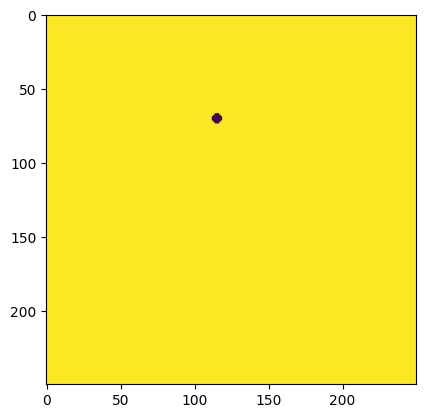

In [ ]:
from PIL import Image, ImageDraw, ImageFont
def sample():

  img=Image.new('RGB',(250,250),(255,255,255))
  draw=ImageDraw.Draw(img)
  random_ncircles=np.random.randint(1,10)
  random_acc=[]
  for i in range(random_ncircles):

    random_cord=[np.random.random(),np.random.random()]
    random_scaled=[random_cord[0]*250,random_cord[1]*250]
    draw.circle(random_scaled,3,fill=(0,0,0))
    random_acc.append(random_scaled)



  #plt.imshow(img)
  #draw a circle
  #draw.ellipse(random_cord,fill=(0,0,0))
  #plt.imshow(img)
  numpyy=np.array(img)
  numpyy=numpyy.mean(2)
  # order random_acc from min to max
  #print(random_acc)
  random_acc.sort(key=lambda x: x[0])
  #print(random_acc)
  random_acc.append([1.0,1.0])
  random_acc=[[2.0,2.0]]+random_acc
  return numpyy,random_acc,random_ncircles

img,acc,ncircles=sample()
plt.imshow(img)

In [ ]:
s=SwinModel(5,10,100,2)
s.train()
#s2=SwinModel2(5,10,100,2)
img=img.reshape((1,250,250,1))
img=torch.tensor(img)
img=img.float()
#make it 3 channels
img=torch.cat([img,img,img],dim=3)
gtt=torch.randn(10,2)
out,distt=s(img,gtt)
print(out)
#print(out)
#optimizer=torch.optim.Adam(s.parameters(),lr=0.001)
#loss=torch.nn.MSELoss()
#lossout=loss(out,gtt)
#lossout.backward()
#print gradients
#for name, param in s.named_parameters():
    #if param.requires_grad:
        #print(name, param.grad)
#optimizer.zero_grad()

#print nparameters
print(sum(p.numel() for p in s.parameters() if p.requires_grad))


s
torch.Size([1, 25, 25, 100])
ex sh
torch.Size([1, 25, 100])
cls 2
torch.Size([100])
cls 2
torch.Size([100])
cls 2
torch.Size([100])
cls 2
torch.Size([100])
cls 2
torch.Size([100])
cls 2
torch.Size([100])
cls 2
torch.Size([100])
cls 2
torch.Size([100])
cls 2
torch.Size([100])
tensor([[0.0000, 0.2182],
        [0.6590, 0.1851],
        [0.6000, 0.2622],
        [0.6490, 0.2361],
        [0.6644, 0.2140],
        [0.7050, 0.2905],
        [0.6538, 0.2215],
        [0.6418, 0.2086],
        [0.6590, 0.0000]], grad_fn=<CopySlices>)
1084944


In [ ]:
def kl_divergencemultiv(p,q):
  kl_sum=0.0
  for i in range(len(p)):
    kl_sum+=torch.distributions.kl.kl_divergence(p[i],q).mean()
  kl_sum=kl_sum/len(p)
  return kl_sum


In [ ]:
#CLEAR OUTPUT
from IPython.display import clear_output

linear.linear.weight tensor([[-2.3600e-06, -2.3600e-06, -2.3600e-06,  ..., -2.3781e-06,
         -2.3781e-06, -2.3781e-06],
        [ 1.3288e-09,  1.3288e-09,  1.3288e-09,  ...,  1.3328e-09,
          1.3328e-09,  1.3328e-09],
        [-1.5530e-10, -1.5530e-10, -1.5530e-10,  ..., -1.5809e-10,
         -1.5809e-10, -1.5809e-10],
        ...,
        [-2.1729e-06, -2.1729e-06, -2.1729e-06,  ..., -2.1866e-06,
         -2.1866e-06, -2.1866e-06],
        [-2.9942e-09, -2.9942e-09, -2.9942e-09,  ..., -3.0126e-09,
         -3.0126e-09, -3.0126e-09],
        [ 4.7742e-07,  4.7742e-07,  4.7742e-07,  ...,  4.9068e-07,
          4.9068e-07,  4.9068e-07]])
linear.linear.bias tensor([-2.3884e-06,  1.3371e-09, -1.5808e-10,  2.5872e-06,  3.2371e-09,
         4.7226e-10,  4.3180e-10, -1.5724e-09, -3.2701e-09, -1.3198e-07,
        -6.1069e-10,  7.1638e-07, -2.8053e-06,  1.3595e-06,  3.8254e-10,
        -5.4338e-06,  7.3391e-12,  4.2258e-06, -5.6608e-06, -3.5968e-07,
        -2.0285e-06, -1.0594e-05,  1

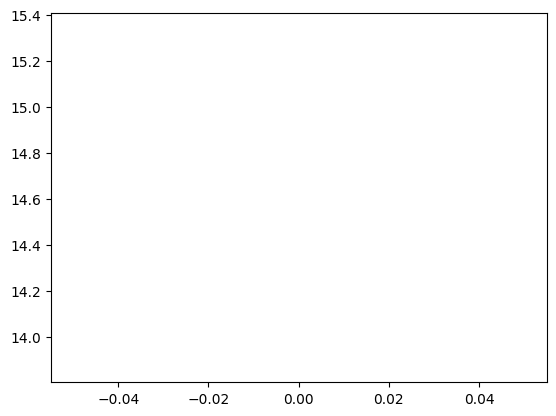

lossk:0.08986706286668777 lossn:0.11931557208299637 lossv:145.9724578857422
tensor([[  2.0000,   2.0000],
        [ 57.1962, 145.1411],
        [ 79.5329, 136.2293],
        [146.3206, 153.2127],
        [147.2672,  95.3319],
        [160.1748, 235.2779],
        [244.7018, 161.2377],
        [  1.0000,   1.0000]])
tensor([[0.2898, 0.4051],
        [0.3250, 0.4104],
        [0.3170, 0.4076],
        [0.2987, 0.3586],
        [0.3701, 0.0000],
        [0.3623, 0.4098],
        [0.3311, 0.4101]], grad_fn=<CopySlices>)
s
torch.Size([1, 25, 25, 100])
ex sh
torch.Size([1, 25, 100])
cls 2
torch.Size([100])
cls 2
torch.Size([100])
cls 2
torch.Size([100])
cls 2
torch.Size([100])
cls 2
torch.Size([100])
lossv
tensor(104.9689, grad_fn=<SmoothL1LossBackward0>)
lossn
tensor(0.1234, grad_fn=<MulBackward0>)
kl_div
tensor(0.0830, grad_fn=<MulBackward0>)


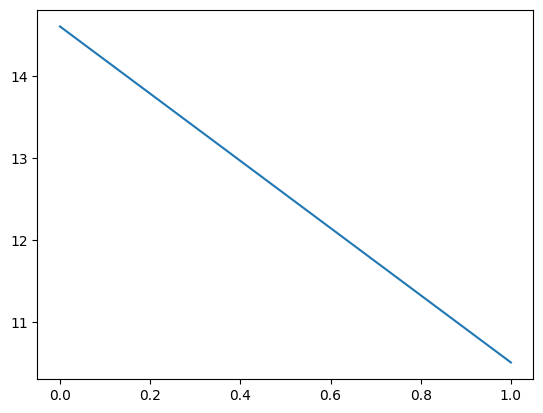

lossk:0.08299505710601807 lossn:0.12339459359645844 lossv:104.96890258789062
tensor([[  2.0000,   2.0000],
        [ 44.5533, 138.8578],
        [ 53.3322, 201.5444],
        [125.9104, 104.0955],
        [127.9539,  50.0866],
        [  1.0000,   1.0000]])
tensor([[0.3394, 0.4101],
        [0.3281, 0.4090],
        [0.2809, 0.4057],
        [0.0000, 0.4098],
        [0.3131, 0.4078]], grad_fn=<CopySlices>)
s
torch.Size([1, 25, 25, 100])
ex sh
torch.Size([1, 25, 100])
cls 2
torch.Size([100])
cls 2
torch.Size([100])
cls 2
torch.Size([100])
cls 2
torch.Size([100])
cls 2
torch.Size([100])
cls 2
torch.Size([100])
cls 2
torch.Size([100])
cls 2
torch.Size([100])
lossv
tensor(137.8780, grad_fn=<SmoothL1LossBackward0>)
lossn
tensor(0.1235, grad_fn=<MulBackward0>)
kl_div
tensor(0.0870, grad_fn=<MulBackward0>)


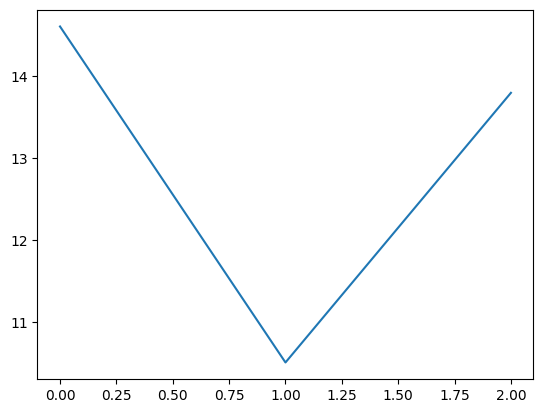

lossk:0.08697891235351562 lossn:0.12349852919578552 lossv:137.8780059814453
tensor([[  2.0000,   2.0000],
        [ 60.1933, 159.8242],
        [119.1525,  48.4895],
        [167.8698, 202.5031],
        [178.5706, 165.0837],
        [187.8645,   6.6206],
        [225.0266,  25.5339],
        [226.4858, 168.7649],
        [  1.0000,   1.0000]])
tensor([[0.2982, 0.4056],
        [0.2965, 0.4067],
        [0.3054, 0.4070],
        [0.3025, 0.4057],
        [0.3385, 0.3761],
        [0.3258, 0.4099],
        [0.0000, 0.4129],
        [0.3124, 0.4079]], grad_fn=<CopySlices>)
s
torch.Size([1, 25, 25, 100])
ex sh
torch.Size([1, 25, 100])
cls 2
torch.Size([100])
cls 2
torch.Size([100])
cls 2
torch.Size([100])
cls 2
torch.Size([100])
cls 2
torch.Size([100])
cls 2
torch.Size([100])
cls 2
torch.Size([100])
lossv
tensor(123.6414, grad_fn=<SmoothL1LossBackward0>)
lossn
tensor(0.1125, grad_fn=<MulBackward0>)
kl_div
tensor(0.0897, grad_fn=<MulBackward0>)


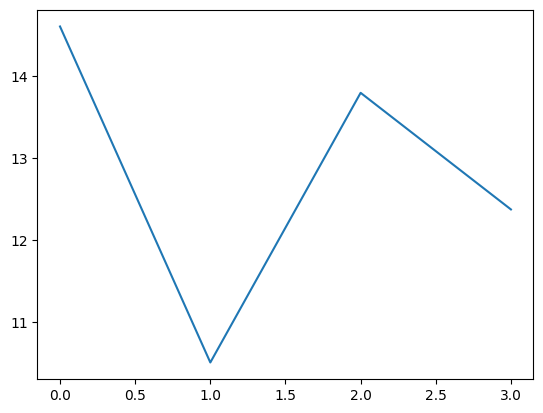

lossk:0.08974111080169678 lossn:0.11247210204601288 lossv:123.64141082763672
tensor([[  2.0000,   2.0000],
        [  9.3490, 211.4624],
        [ 23.4378,  94.9004],
        [110.8292,  91.7378],
        [134.2434, 220.2392],
        [143.2895, 177.3191],
        [210.1736,  66.3227],
        [  1.0000,   1.0000]])
tensor([[0.2856, 0.4037],
        [0.0000, 0.3682],
        [0.0000, 0.4060],
        [0.3442, 0.4101],
        [0.3157, 0.4078],
        [0.3123, 0.3536],
        [0.3638, 0.4126]], grad_fn=<CopySlices>)
s
torch.Size([1, 25, 25, 100])
ex sh
torch.Size([1, 25, 100])
cls 2
torch.Size([100])
cls 2
torch.Size([100])
cls 2
torch.Size([100])
lossv
tensor(201.8558, grad_fn=<SmoothL1LossBackward0>)
lossn
tensor(0.1243, grad_fn=<MulBackward0>)
kl_div
tensor(0.0868, grad_fn=<MulBackward0>)


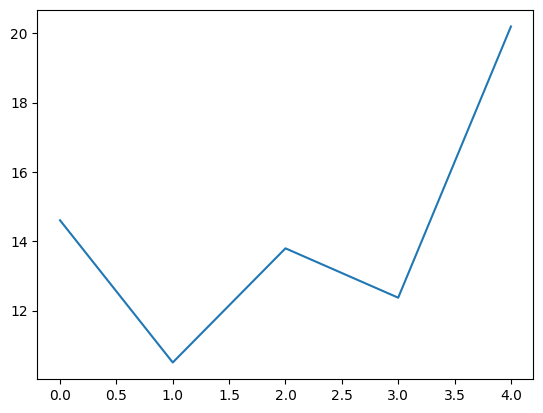

lossk:0.08678486198186874 lossn:0.12433315068483353 lossv:201.8557891845703
tensor([[  2.0000,   2.0000],
        [197.4238, 199.0786],
        [216.0910, 198.1715],
        [  1.0000,   1.0000]])
tensor([[0.1908, 0.3974],
        [0.3432, 0.4103],
        [0.3090, 0.4072]], grad_fn=<CopySlices>)
s
torch.Size([1, 25, 25, 100])
ex sh
torch.Size([1, 25, 100])
cls 2
torch.Size([100])
cls 2
torch.Size([100])
cls 2
torch.Size([100])
cls 2
torch.Size([100])
cls 2
torch.Size([100])
cls 2
torch.Size([100])
cls 2
torch.Size([100])
cls 2
torch.Size([100])
cls 2
torch.Size([100])
cls 2
torch.Size([100])
lossv
tensor(152.2641, grad_fn=<SmoothL1LossBackward0>)
lossn
tensor(0.1197, grad_fn=<MulBackward0>)
kl_div
tensor(0.0869, grad_fn=<MulBackward0>)


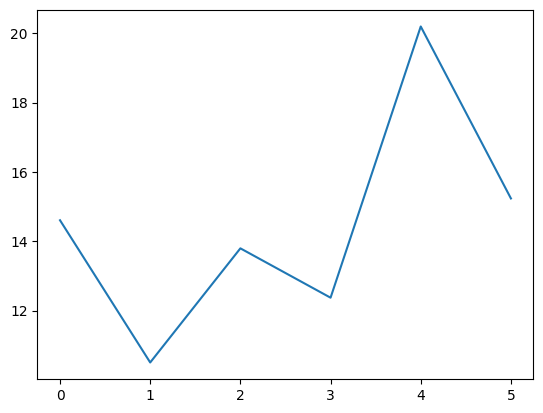

lossk:0.08690313994884491 lossn:0.1197376400232315 lossv:152.2641143798828
tensor([[  2.0000,   2.0000],
        [  3.4592, 243.5063],
        [ 96.1496, 190.9746],
        [100.1619, 183.8460],
        [160.7439, 164.7221],
        [210.1863,  26.5623],
        [227.5693,  92.5376],
        [231.5298, 117.5286],
        [240.3833, 216.2474],
        [243.1862,   7.0011],
        [  1.0000,   1.0000]])
tensor([[0.3235, 0.3887],
        [0.2913, 0.4018],
        [0.3333, 0.4109],
        [0.3361, 0.4112],
        [0.3267, 0.4067],
        [0.3104, 0.3661],
        [0.3235, 0.4088],
        [0.3505, 0.4108],
        [0.3323, 0.4091],
        [0.3300, 0.4089]], grad_fn=<CopySlices>)
s
torch.Size([1, 25, 25, 100])
ex sh
torch.Size([1, 25, 100])
cls 2
torch.Size([100])
cls 2
torch.Size([100])
cls 2
torch.Size([100])
cls 2
torch.Size([100])
cls 2
torch.Size([100])
cls 2
torch.Size([100])
cls 2
torch.Size([100])
cls 2
torch.Size([100])
lossv
tensor(106.9930, grad_fn=<SmoothL1LossBackward0>)
l

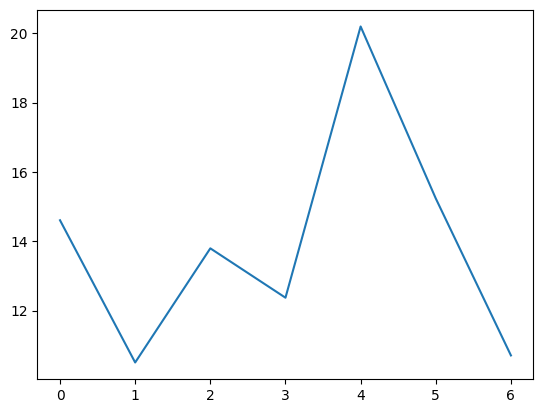

lossk:0.09261351078748703 lossn:0.12226950377225876 lossv:106.9930191040039
tensor([[  2.0000,   2.0000],
        [  6.5472, 133.7542],
        [ 22.3825,  32.5400],
        [ 32.1224, 224.1306],
        [ 41.4637,  16.1878],
        [131.7792, 208.2383],
        [214.3137,   0.9909],
        [234.2416, 210.6835],
        [  1.0000,   1.0000]])
tensor([[0.3414, 0.3899],
        [0.2905, 0.3837],
        [0.3093, 0.4078],
        [0.3356, 0.4105],
        [0.3179, 0.0000],
        [0.3198, 0.3568],
        [0.2929, 0.3840],
        [0.3292, 0.3957]], grad_fn=<CopySlices>)
s
torch.Size([1, 25, 25, 100])
ex sh
torch.Size([1, 25, 100])
cls 2
torch.Size([100])
cls 2
torch.Size([100])
cls 2
torch.Size([100])
cls 2
torch.Size([100])
cls 2
torch.Size([100])
cls 2
torch.Size([100])
cls 2
torch.Size([100])
lossv
tensor(129.9292, grad_fn=<SmoothL1LossBackward0>)
lossn
tensor(0.1127, grad_fn=<MulBackward0>)
kl_div
tensor(0.0875, grad_fn=<MulBackward0>)


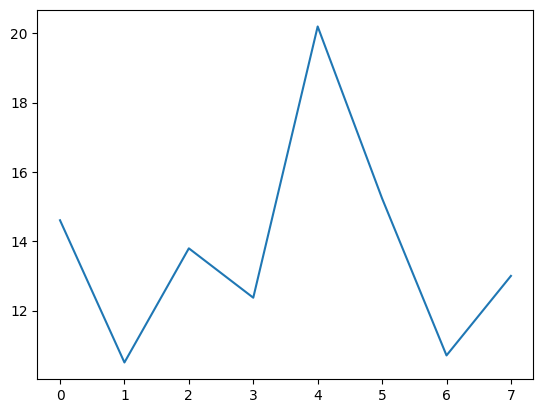

lossk:0.08752711117267609 lossn:0.11270160228013992 lossv:129.9292449951172
tensor([[  2.0000,   2.0000],
        [133.2457,  67.2640],
        [150.0052,  47.7495],
        [153.5167, 197.0612],
        [160.1775,  80.9798],
        [225.8850,  36.8150],
        [226.7692,  89.2131],
        [  1.0000,   1.0000]])
tensor([[0.3130, 0.4071],
        [0.3493, 0.4123],
        [0.3305, 0.0000],
        [0.2960, 0.4069],
        [0.2938, 0.0000],
        [0.3151, 0.4072],
        [0.3628, 0.4124]], grad_fn=<CopySlices>)
s
torch.Size([1, 25, 25, 100])
ex sh
torch.Size([1, 25, 100])
cls 2
torch.Size([100])
cls 2
torch.Size([100])
cls 2
torch.Size([100])
cls 2
torch.Size([100])
cls 2
torch.Size([100])
cls 2
torch.Size([100])
cls 2
torch.Size([100])
cls 2
torch.Size([100])
lossv
tensor(139.6815, grad_fn=<SmoothL1LossBackward0>)
lossn
tensor(0.2023, grad_fn=<MulBackward0>)
kl_div
tensor(0.0927, grad_fn=<MulBackward0>)


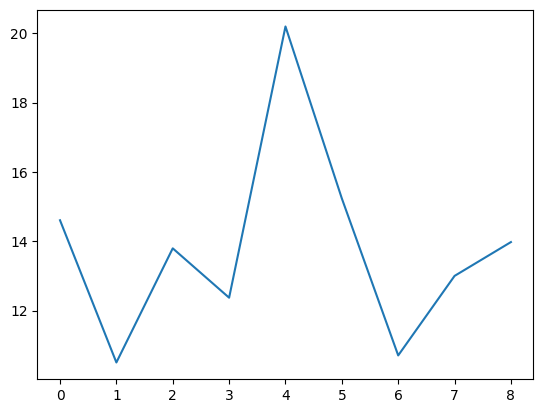

lossk:0.09272859990596771 lossn:0.202322319149971 lossv:139.6814727783203
tensor([[  2.0000,   2.0000],
        [ 50.5884,  39.4002],
        [ 86.2220,  96.9231],
        [147.7088,  64.1127],
        [176.1103, 195.3528],
        [182.5987, 226.3776],
        [194.7689, 111.9731],
        [199.8248, 195.1375],
        [  1.0000,   1.0000]])
tensor([[0.3000, 0.4066],
        [0.3155, 0.3708],
        [0.1898, 0.3960],
        [0.3495, 0.4106],
        [0.3251, 0.4081],
        [0.0000, 0.4106],
        [0.3253, 0.3502],
        [0.0000, 0.4094]], grad_fn=<CopySlices>)
s
torch.Size([1, 25, 25, 100])
ex sh
torch.Size([1, 25, 100])
cls 2
torch.Size([100])
cls 2
torch.Size([100])
cls 2
torch.Size([100])
cls 2
torch.Size([100])
cls 2
torch.Size([100])
cls 2
torch.Size([100])
cls 2
torch.Size([100])
cls 2
torch.Size([100])
cls 2
torch.Size([100])
lossv
tensor(122.5861, grad_fn=<SmoothL1LossBackward0>)
lossn
tensor(0.1152, grad_fn=<MulBackward0>)
kl_div
tensor(0.0853, grad_fn=<MulBackward0>)

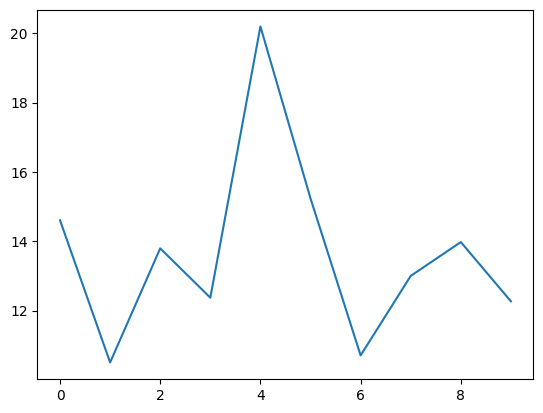

lossk:0.0852794274687767 lossn:0.11520571261644363 lossv:122.58609771728516
tensor([[  2.0000,   2.0000],
        [ 22.6358, 235.9523],
        [ 69.3451,  75.3972],
        [ 75.9236, 159.6158],
        [ 98.6577, 237.0926],
        [ 99.5654,  11.4280],
        [118.0086, 213.6764],
        [146.3476, 103.0673],
        [156.0865, 152.3688],
        [  1.0000,   1.0000]])
tensor([[0.3298, 0.4092],
        [0.3060, 0.3986],
        [0.3499, 0.4117],
        [0.2983, 0.3906],
        [0.3055, 0.4055],
        [0.3056, 0.4082],
        [0.2860, 0.4051],
        [0.3685, 0.4128],
        [0.3515, 0.4105]], grad_fn=<CopySlices>)
s
torch.Size([1, 25, 25, 100])
ex sh
torch.Size([1, 25, 100])
cls 2
torch.Size([100])
cls 2
torch.Size([100])
cls 2
torch.Size([100])
cls 2
torch.Size([100])
cls 2
torch.Size([100])
cls 2
torch.Size([100])
lossv
tensor(130.0112, grad_fn=<SmoothL1LossBackward0>)
lossn
tensor(0.1153, grad_fn=<MulBackward0>)
kl_div
tensor(0.0881, grad_fn=<MulBackward0>)


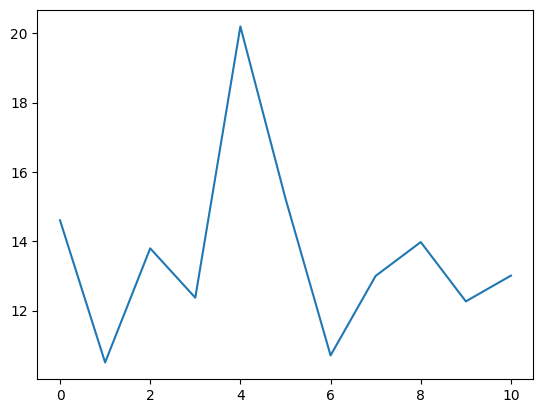

lossk:0.08809464424848557 lossn:0.11526250094175339 lossv:130.01116943359375
tensor([[  2.0000,   2.0000],
        [ 45.3056, 141.6052],
        [ 80.5932,  65.9763],
        [147.8961, 133.3724],
        [188.4124,  79.0014],
        [244.4893, 181.5799],
        [  1.0000,   1.0000]])
tensor([[0.3484, 0.4257],
        [0.3662, 0.0000],
        [0.3424, 0.4232],
        [0.3608, 0.4254],
        [0.0000, 0.4278],
        [0.3386, 0.4247]], grad_fn=<CopySlices>)
s
torch.Size([1, 25, 25, 100])
ex sh
torch.Size([1, 25, 100])
cls 2
torch.Size([100])
cls 2
torch.Size([100])
cls 2
torch.Size([100])
cls 2
torch.Size([100])
cls 2
torch.Size([100])
cls 2
torch.Size([100])
cls 2
torch.Size([100])
cls 2
torch.Size([100])
cls 2
torch.Size([100])
lossv
tensor(131.9708, grad_fn=<SmoothL1LossBackward0>)
lossn
tensor(0.1253, grad_fn=<MulBackward0>)
kl_div
tensor(0.0916, grad_fn=<MulBackward0>)


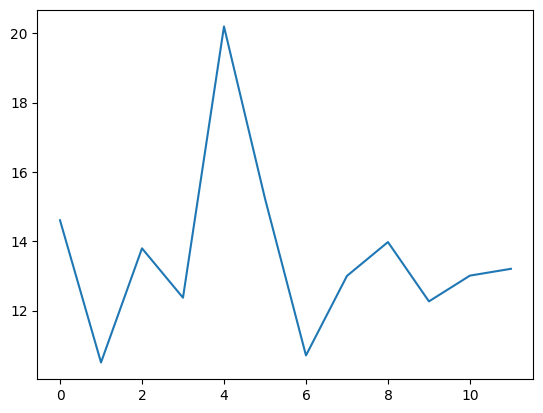

lossk:0.09159135818481445 lossn:0.12532711029052734 lossv:131.9708251953125
tensor([[2.0000e+00, 2.0000e+00],
        [3.2729e+01, 1.6611e+02],
        [5.8313e+01, 3.7557e+01],
        [7.8504e+01, 8.2456e-02],
        [1.1497e+02, 2.0980e+02],
        [1.2224e+02, 2.2461e+02],
        [2.2000e+02, 2.2569e+02],
        [2.2882e+02, 9.6417e+01],
        [2.4276e+02, 6.5902e+01],
        [1.0000e+00, 1.0000e+00]])
tensor([[0.0000, 0.3991],
        [0.3758, 0.4297],
        [0.3360, 0.4222],
        [0.3231, 0.4058],
        [0.3683, 0.4306],
        [0.4002, 0.4301],
        [0.3298, 0.4244],
        [0.3528, 0.4269],
        [0.3673, 0.3403]], grad_fn=<CopySlices>)
s
torch.Size([1, 25, 25, 100])
ex sh
torch.Size([1, 25, 100])
cls 2
torch.Size([100])
cls 2
torch.Size([100])
cls 2
torch.Size([100])
lossv
tensor(213.2292, grad_fn=<SmoothL1LossBackward0>)
lossn
tensor(0.1202, grad_fn=<MulBackward0>)
kl_div
tensor(0.0810, grad_fn=<MulBackward0>)


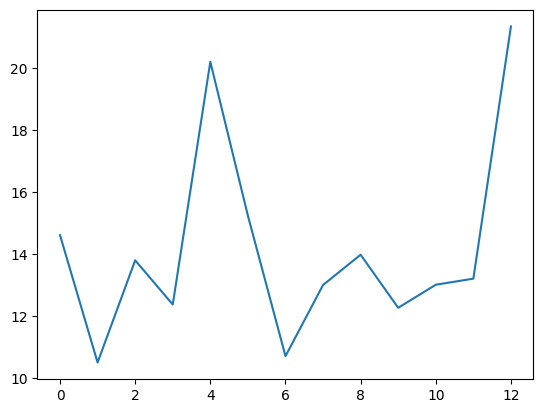

lossk:0.08096122741699219 lossn:0.12016523629426956 lossv:213.22923278808594
tensor([[  2.0000,   2.0000],
        [212.2423, 223.2159],
        [247.7997, 173.2248],
        [  1.0000,   1.0000]])
tensor([[0.4017, 0.4311],
        [0.3476, 0.3854],
        [0.3169, 0.4216]], grad_fn=<CopySlices>)
s
torch.Size([1, 25, 25, 100])
ex sh
torch.Size([1, 25, 100])
cls 2
torch.Size([100])
cls 2
torch.Size([100])
cls 2
torch.Size([100])
cls 2
torch.Size([100])
cls 2
torch.Size([100])
cls 2
torch.Size([100])
cls 2
torch.Size([100])
cls 2
torch.Size([100])
lossv
tensor(122.9220, grad_fn=<SmoothL1LossBackward0>)
lossn
tensor(0.1128, grad_fn=<MulBackward0>)
kl_div
tensor(0.0909, grad_fn=<MulBackward0>)


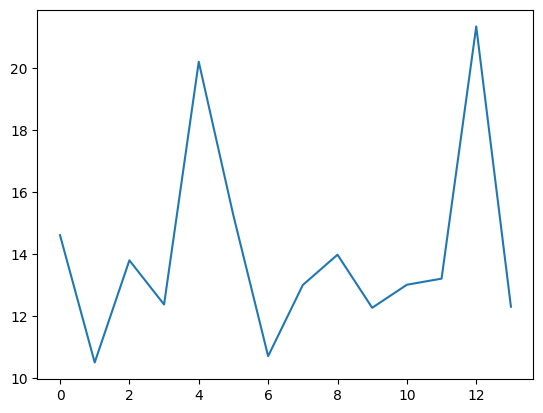

lossk:0.09086143970489502 lossn:0.1127747967839241 lossv:122.92203521728516
tensor([[  2.0000,   2.0000],
        [ 62.8046, 121.8157],
        [ 88.5018,  76.3909],
        [110.2657,  17.6496],
        [114.5033, 109.1361],
        [145.4286, 206.0579],
        [163.8350, 136.2372],
        [189.5081, 189.9704],
        [  1.0000,   1.0000]])
tensor([[0.3650, 0.0000],
        [0.3343, 0.4239],
        [0.3301, 0.4241],
        [0.3873, 0.4310],
        [0.3251, 0.4127],
        [0.3377, 0.4252],
        [0.0000, 0.0000],
        [0.3503, 0.4258]], grad_fn=<CopySlices>)
s
torch.Size([1, 25, 25, 100])
ex sh
torch.Size([1, 25, 100])
cls 2
torch.Size([100])
cls 2
torch.Size([100])
cls 2
torch.Size([100])
cls 2
torch.Size([100])
cls 2
torch.Size([100])
cls 2
torch.Size([100])
cls 2
torch.Size([100])
lossv
tensor(77.9256, grad_fn=<SmoothL1LossBackward0>)
lossn
tensor(0.1160, grad_fn=<MulBackward0>)
kl_div
tensor(0.0998, grad_fn=<MulBackward0>)


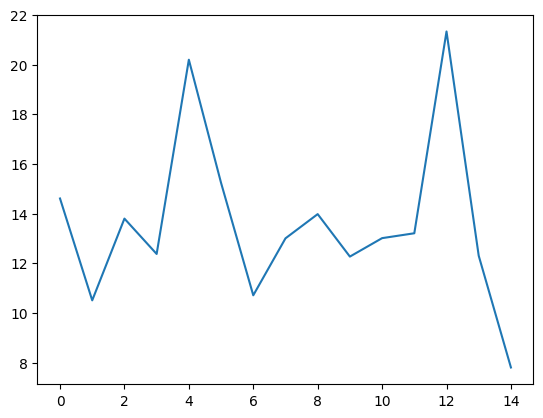

lossk:0.09979013353586197 lossn:0.11596082895994186 lossv:77.9256362915039
tensor([[  2.0000,   2.0000],
        [  0.3790,  52.4794],
        [  6.5844, 110.2436],
        [ 85.7382,  87.8730],
        [120.8584, 118.1314],
        [121.4012,   7.9796],
        [172.8951,  60.3035],
        [  1.0000,   1.0000]])
tensor([[0.3472, 0.4259],
        [0.3296, 0.4231],
        [0.3414, 0.4246],
        [0.3968, 0.0000],
        [0.3429, 0.4283],
        [0.3435, 0.4247],
        [0.3354, 0.4244]], grad_fn=<CopySlices>)
s
torch.Size([1, 25, 25, 100])
ex sh
torch.Size([1, 25, 100])
cls 2
torch.Size([100])
cls 2
torch.Size([100])
cls 2
torch.Size([100])
cls 2
torch.Size([100])
cls 2
torch.Size([100])
cls 2
torch.Size([100])
cls 2
torch.Size([100])
lossv
tensor(164.6463, grad_fn=<SmoothL1LossBackward0>)
lossn
tensor(0.1177, grad_fn=<MulBackward0>)
kl_div
tensor(0.0896, grad_fn=<MulBackward0>)


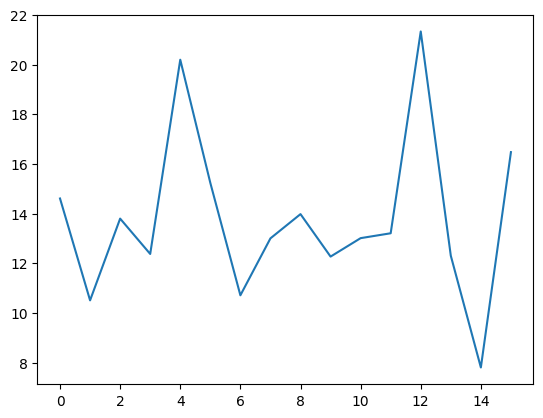

lossk:0.08956257253885269 lossn:0.11769118905067444 lossv:164.64625549316406
tensor([[  2.0000,   2.0000],
        [ 93.5289, 195.6123],
        [155.2646,   1.8082],
        [170.7301, 232.3820],
        [200.3105, 242.9273],
        [217.6609,  51.9484],
        [225.0000, 198.9610],
        [  1.0000,   1.0000]])
tensor([[0.3545, 0.4275],
        [0.3510, 0.4258],
        [0.4075, 0.4347],
        [0.0000, 0.4311],
        [0.3422, 0.4246],
        [0.3537, 0.4267],
        [0.3271, 0.4240]], grad_fn=<CopySlices>)
s
torch.Size([1, 25, 25, 100])
ex sh
torch.Size([1, 25, 100])
cls 2
torch.Size([100])
cls 2
torch.Size([100])
cls 2
torch.Size([100])
cls 2
torch.Size([100])
cls 2
torch.Size([100])
cls 2
torch.Size([100])
cls 2
torch.Size([100])
cls 2
torch.Size([100])
lossv
tensor(135.8381, grad_fn=<SmoothL1LossBackward0>)
lossn
tensor(0.1981, grad_fn=<MulBackward0>)
kl_div
tensor(0.0864, grad_fn=<MulBackward0>)


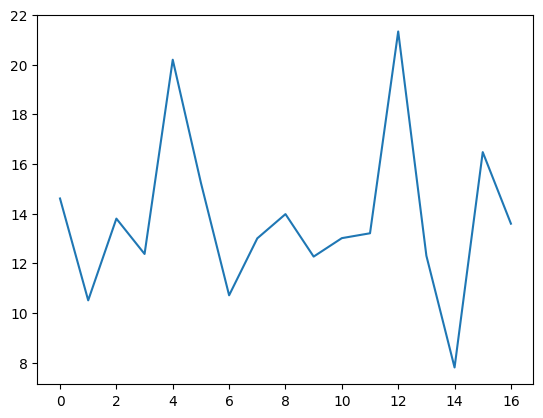

lossk:0.08644988387823105 lossn:0.1981441229581833 lossv:135.8380584716797
tensor([[  2.0000,   2.0000],
        [  3.4512, 127.3711],
        [ 33.2758, 236.3974],
        [ 95.0614, 115.9706],
        [171.7875,  46.7588],
        [202.7904,  25.4796],
        [213.7916, 198.6008],
        [237.4876, 204.8844],
        [  1.0000,   1.0000]])
tensor([[0.2970, 0.4172],
        [0.0000, 0.0000],
        [0.3500, 0.4251],
        [0.3864, 0.4297],
        [0.0000, 0.4297],
        [0.3952, 0.4324],
        [0.3830, 0.4294],
        [0.0000, 0.4335]], grad_fn=<CopySlices>)
s
torch.Size([1, 25, 25, 100])
ex sh
torch.Size([1, 25, 100])
cls 2
torch.Size([100])
cls 2
torch.Size([100])
cls 2
torch.Size([100])
cls 2
torch.Size([100])
lossv
tensor(147.5066, grad_fn=<SmoothL1LossBackward0>)
lossn
tensor(0.1127, grad_fn=<MulBackward0>)
kl_div
tensor(0.0987, grad_fn=<MulBackward0>)


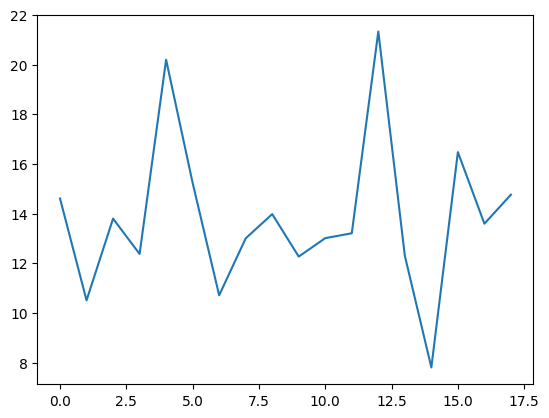

lossk:0.09873726218938828 lossn:0.11274371296167374 lossv:147.50660705566406
tensor([[  2.0000,   2.0000],
        [127.1128, 228.9667],
        [185.0353,  75.1224],
        [241.9895,  32.0598],
        [  1.0000,   1.0000]])
tensor([[0.3198, 0.4113],
        [0.3687, 0.4284],
        [0.3189, 0.3997],
        [0.3517, 0.4244]], grad_fn=<CopySlices>)
s
torch.Size([1, 25, 25, 100])
ex sh
torch.Size([1, 25, 100])
cls 2
torch.Size([100])
cls 2
torch.Size([100])
cls 2
torch.Size([100])
cls 2
torch.Size([100])
cls 2
torch.Size([100])
lossv
tensor(141.7543, grad_fn=<SmoothL1LossBackward0>)
lossn
tensor(0.1265, grad_fn=<MulBackward0>)
kl_div
tensor(0.1003, grad_fn=<MulBackward0>)


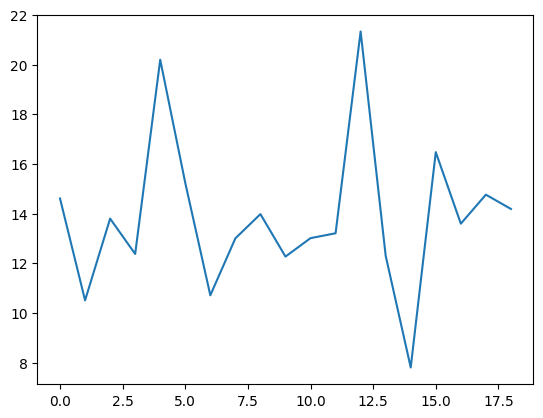

lossk:0.1002633199095726 lossn:0.12653908133506775 lossv:141.7542724609375
tensor([[  2.0000,   2.0000],
        [ 15.6624, 147.3914],
        [137.0263, 216.3789],
        [200.2014, 169.4572],
        [215.7119,  39.2176],
        [  1.0000,   1.0000]])
tensor([[0.3389, 0.4254],
        [0.3230, 0.4037],
        [0.3431, 0.4255],
        [0.3688, 0.3846],
        [0.2901, 0.4172]], grad_fn=<CopySlices>)
s
torch.Size([1, 25, 25, 100])
ex sh
torch.Size([1, 25, 100])
cls 2
torch.Size([100])
cls 2
torch.Size([100])
cls 2
torch.Size([100])
cls 2
torch.Size([100])
cls 2
torch.Size([100])
cls 2
torch.Size([100])
lossv
tensor(134.0940, grad_fn=<SmoothL1LossBackward0>)
lossn
tensor(0.1129, grad_fn=<MulBackward0>)
kl_div
tensor(0.0872, grad_fn=<MulBackward0>)


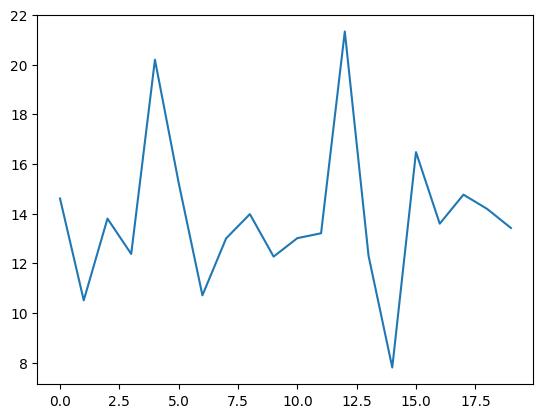

lossk:0.08718191832304001 lossn:0.11294243484735489 lossv:134.0940399169922
tensor([[  2.0000,   2.0000],
        [ 65.1906, 137.4420],
        [ 67.2826,  16.4948],
        [103.8173, 197.7750],
        [169.4000, 206.3573],
        [198.2537, 187.0192],
        [  1.0000,   1.0000]])
tensor([[0.0000, 0.4275],
        [0.3030, 0.4185],
        [0.0000, 0.4275],
        [0.3282, 0.4239],
        [0.3388, 0.4248],
        [0.3586, 0.4156]], grad_fn=<CopySlices>)
s
torch.Size([1, 25, 25, 100])
ex sh
torch.Size([1, 25, 100])
cls 2
torch.Size([100])
cls 2
torch.Size([100])
cls 2
torch.Size([100])
cls 2
torch.Size([100])
lossv
tensor(151.2350, grad_fn=<SmoothL1LossBackward0>)
lossn
tensor(0.1095, grad_fn=<MulBackward0>)
kl_div
tensor(0.0872, grad_fn=<MulBackward0>)


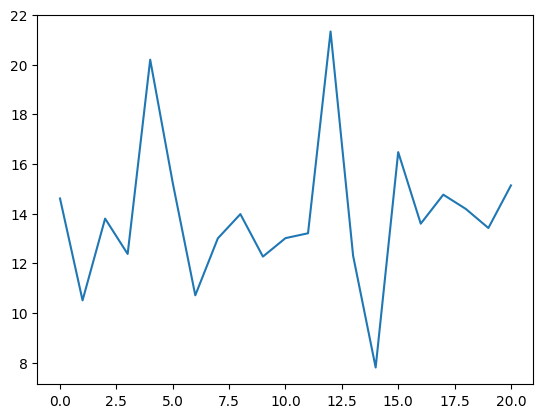

lossk:0.0872301459312439 lossn:0.10950352996587753 lossv:151.23504638671875
tensor([[  2.0000,   2.0000],
        [ 39.2094, 155.2192],
        [164.4123, 164.2310],
        [173.0514, 216.3366],
        [  1.0000,   1.0000]])
tensor([[0.4239, 0.0000],
        [0.3627, 0.4395],
        [0.3802, 0.4434],
        [0.3537, 0.4412]], grad_fn=<CopySlices>)
s
torch.Size([1, 25, 25, 100])
ex sh
torch.Size([1, 25, 100])
cls 2
torch.Size([100])
cls 2
torch.Size([100])
cls 2
torch.Size([100])
lossv
tensor(145.5295, grad_fn=<SmoothL1LossBackward0>)
lossn
tensor(0.0869, grad_fn=<MulBackward0>)
kl_div
tensor(0.0836, grad_fn=<MulBackward0>)


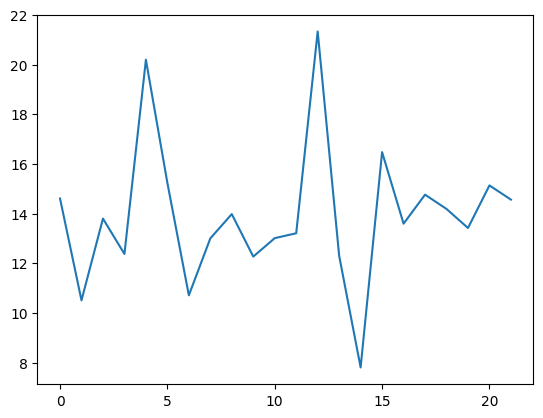

lossk:0.08358359336853027 lossn:0.0868605449795723 lossv:145.529541015625
tensor([[  2.0000,   2.0000],
        [211.9614,   8.0344],
        [246.2511, 119.1340],
        [  1.0000,   1.0000]])
tensor([[0.2130, 0.4184],
        [0.2130, 0.4183],
        [0.4658, 0.4581]], grad_fn=<CopySlices>)
s
torch.Size([1, 25, 25, 100])
ex sh
torch.Size([1, 25, 100])
cls 2
torch.Size([100])
cls 2
torch.Size([100])
cls 2
torch.Size([100])
cls 2
torch.Size([100])
cls 2
torch.Size([100])
lossv
tensor(136.4065, grad_fn=<SmoothL1LossBackward0>)
lossn
tensor(0.0960, grad_fn=<MulBackward0>)
kl_div
tensor(0.0841, grad_fn=<MulBackward0>)


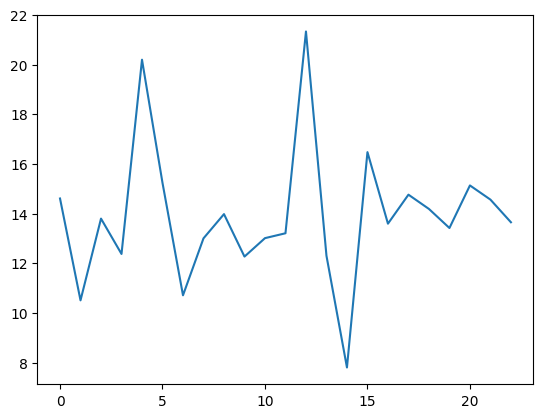

lossk:0.08407356590032578 lossn:0.09598792344331741 lossv:136.40646362304688
tensor([[  2.0000,   2.0000],
        [ 36.8404, 176.6772],
        [ 44.8693, 225.3755],
        [ 57.3298, 249.1780],
        [188.7345, 119.3042],
        [  1.0000,   1.0000]])
tensor([[0.2130, 0.4189],
        [0.3891, 0.4189],
        [0.3870, 0.4458],
        [0.3800, 0.4045],
        [0.4193, 0.4498]], grad_fn=<CopySlices>)
s
torch.Size([1, 25, 25, 100])
ex sh
torch.Size([1, 25, 100])
cls 2
torch.Size([100])
cls 2
torch.Size([100])
cls 2
torch.Size([100])
cls 2
torch.Size([100])
cls 2
torch.Size([100])
cls 2
torch.Size([100])
cls 2
torch.Size([100])
cls 2
torch.Size([100])
lossv
tensor(126.3156, grad_fn=<SmoothL1LossBackward0>)
lossn
tensor(0.0828, grad_fn=<MulBackward0>)
kl_div
tensor(0.0814, grad_fn=<MulBackward0>)


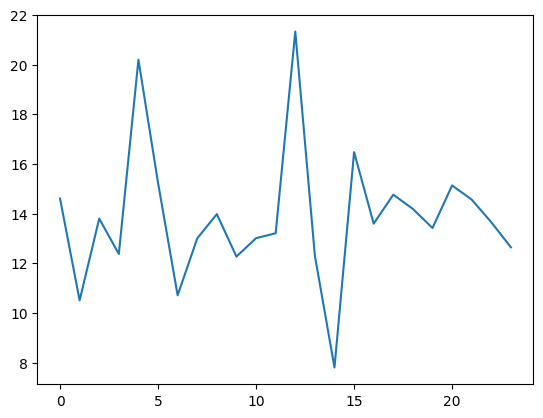

lossk:0.08142422139644623 lossn:0.08280140161514282 lossv:126.31556701660156
tensor([[  2.0000,   2.0000],
        [  3.9980, 133.4141],
        [ 25.1531, 125.1090],
        [ 33.4920,  59.1073],
        [172.2035, 247.8188],
        [201.2342,  75.8789],
        [204.8940,  69.5311],
        [248.4185, 180.6376],
        [  1.0000,   1.0000]])
tensor([[0.4254, 0.4496],
        [0.3524, 0.4035],
        [0.0000, 0.4457],
        [0.4098, 0.4491],
        [0.4532, 0.4561],
        [0.3281, 0.4359],
        [0.4131, 0.4501],
        [0.4902, 0.4595]], grad_fn=<CopySlices>)
s
torch.Size([1, 25, 25, 100])
ex sh
torch.Size([1, 25, 100])
cls 2
torch.Size([100])
cls 2
torch.Size([100])
cls 2
torch.Size([100])
cls 2
torch.Size([100])
cls 2
torch.Size([100])
cls 2
torch.Size([100])
cls 2
torch.Size([100])
lossv
tensor(130.1915, grad_fn=<SmoothL1LossBackward0>)
lossn
tensor(0.0978, grad_fn=<MulBackward0>)
kl_div
tensor(0.0842, grad_fn=<MulBackward0>)


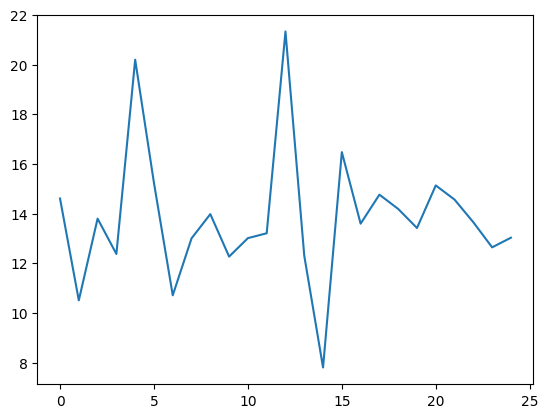

lossk:0.08423971384763718 lossn:0.09782163053750992 lossv:130.1915283203125
tensor([[  2.0000,   2.0000],
        [ 58.0397, 143.4198],
        [ 96.2622, 154.6476],
        [116.8876,  63.4007],
        [133.6147, 154.2683],
        [134.6903, 120.0197],
        [169.5454, 227.6721],
        [  1.0000,   1.0000]])
tensor([[0.0000, 0.4493],
        [0.4107, 0.4494],
        [0.4532, 0.4545],
        [0.3762, 0.4440],
        [0.3836, 0.0000],
        [0.3765, 0.3725],
        [0.4100, 0.4486]], grad_fn=<CopySlices>)
s
torch.Size([1, 25, 25, 100])
ex sh
torch.Size([1, 25, 100])
cls 2
torch.Size([100])
cls 2
torch.Size([100])
cls 2
torch.Size([100])
lossv
tensor(123.9896, grad_fn=<SmoothL1LossBackward0>)
lossn
tensor(0.0977, grad_fn=<MulBackward0>)
kl_div
tensor(0.0883, grad_fn=<MulBackward0>)


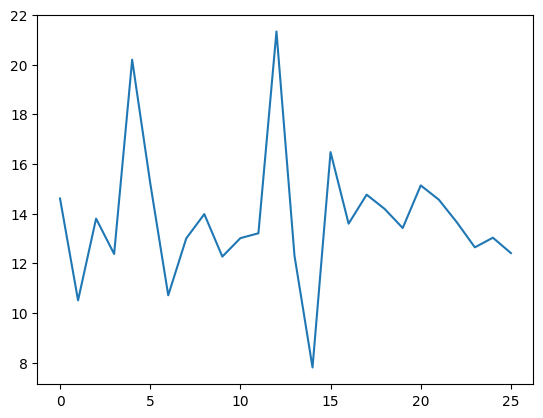

lossk:0.08825856447219849 lossn:0.09771237522363663 lossv:123.9896469116211
tensor([[  2.0000,   2.0000],
        [132.7928, 179.1640],
        [147.1000,  40.5650],
        [  1.0000,   1.0000]])
tensor([[0.3518, 0.4400],
        [0.4193, 0.4522],
        [0.4105, 0.4488]], grad_fn=<CopySlices>)


KeyboardInterrupt: 

In [ ]:
#training loop
learning_rate=0.01
epochs=1000
lambdav=1
tau=0.6
optimizer=torch.optim.Adam(s.parameters(),lr=learning_rate)
loss=torch.nn.SmoothL1Loss()
s.train()
normal_dist=torch.distributions.normal.Normal(0,1)
batch_acc_steps=10
losses=[]
for i in range(epochs):
  inp,target,n_circles=sample()
  inp=torch.from_numpy(inp).float()
  target=np.array(target)
  target=torch.from_numpy(target).float()
  #make 3 channel
  #inp=inp.unsqueeze(0)
  inp=inp.repeat(3,1,1)
  #print("inp")
  #print(inp)
  #normalize
  inp=inp/255
  #print("inp2")
  #print(inp)
  inp=torch.permute(inp,(1,2,0))
  inp=inp.unsqueeze(0)
  pred,dist=s(inp,target)
  #print(pred.shape)
  ftarget,starget=target[1:-1,:],target[-1,:]
  fpred,spred=pred[:-1,:],pred[-1,:]
  fpred=fpred
  spred=spred
  #print(target.shape)
  #print(pred.shape)

  lossv=loss(fpred,ftarget)
  lossn=loss(spred,starget)*tau
  print("lossv")
  print(lossv)
  print("lossn")
  print(lossn)
  #kl_div=torch.distributions.kl.kl_divergence(dist,normal_dist)
  #print(dist)
  kl_div=kl_divergencemultiv(dist,normal_dist)
  lossk=lambdav*kl_div
  print("kl_div")
  print(lossk)
  total_loss=(lossv+lossk)/batch_acc_steps
  total_loss.backward()
  total_loss=total_loss.detach().numpy()
  #lossk=lossk.detach().numpy()
  lossn=lossn.detach().numpy()
  lossv=lossv.detach().numpy()
  losses.append(total_loss)
  plt.plot(losses)
  plt.show()
  if (i+1)%30==0:
    clear_output()
    losses=[]
    #print gradients
    for name, param in s.named_parameters():
      if param.grad is not None:
        print(name, param.grad)




  if (i+1)%batch_acc_steps==0:
    #clip grad

    torch.nn.utils.clip_grad_norm_(s.parameters(), 1)
    optimizer.step()
    optimizer.zero_grad()
  print(f"lossk:{lossk} lossn:{lossn} lossv:{lossv}")
  print(target)
  print(pred)
  #print(pred)
  #print(target)




  #print(inp.shape)

  #print(target)
  #print(inp.shape)


In [ ]:
#print weights
for name, param in s.named_parameters():
  if param.requires_grad:
    print(name, param.data)

cls tensor([[[[1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
           1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
           1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
           1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
           1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
           1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
           1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
           1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
           1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
           1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
           1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
           1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
           1., 1., 1., 1., 1., 1., 1., 1., 1., 1

In [ ]:
#training loop2
learning_rate=0.001
epochs=1000
lambdav=400
tau=0.6
optimizer=torch.optim.Adam(s2.parameters(),lr=learning_rate)
loss=torch.nn.SmoothL1Loss()
s2.train()
normal_dist=torch.distributions.normal.Normal(0,1)
batch_acc_steps=10
losses=[]
for i in range(epochs):
  inp,target,n_circles=sample()
  inp=torch.from_numpy(inp).float()
  target=np.array(target)
  target=torch.from_numpy(target).float()
  #make 3 channel
  #inp=inp.unsqueeze(0)
  inp=inp.repeat(3,1,1)
  inp=torch.permute(inp,(1,2,0))
  inp=inp.unsqueeze(0)
  pred=s2(inp,target)
  #print(pred.shape)
  ftarget,starget=target[1:-1,:],target[-1,:]
  fpred,spred=pred[:-1,:],pred[-1,:]
  fpred=fpred*250
  spred=spred*250
  #print(target.shape)
  #print(pred.shape)

  lossv=loss(fpred,ftarget)
  lossn=loss(spred,starget)*tau
  print("lossv")
  print(lossv)
  print("lossn")
  print(lossn)
  #kl_div=torch.distributions.kl.kl_divergence(dist,normal_dist)
  #print(dist)
  #kl_div=kl_divergencemultiv(dist,normal_dist)
  #lossk=lambdav*kl_div
  print("kl_div")
  print(lossk)
  total_loss=(lossv)/batch_acc_steps
  total_loss.backward()
  total_loss=total_loss.detach().numpy()
  #lossk=lossk.detach().numpy()
  lossn=lossn.detach().numpy()
  lossv=lossv.detach().numpy()
  losses.append(total_loss)
  plt.plot(losses)
  plt.show()
  if (i+1)%30==0:
    clear_output()
    losses=[]
    #print gradients
    for name, param in s2.named_parameters():
      if param.grad is not None:
        print(name, param.grad)




  if (i+1)%batch_acc_steps==0:
    #clip grad

    torch.nn.utils.clip_grad_norm_(s.parameters(), 1)
    optimizer.step()
    optimizer.zero_grad()
  print(f"lossk:{lossk} lossn:{lossn} lossv:{lossv}")
  print(target)
  print(pred*250)
  #print(pred)
  #print(target)




  #print(inp.shape)

  #print(target)
  #print(inp.shape)
